# Implementation of Quantitative Data Analysis Using Python

### **Programme:** MSAI, The Open University of Kenya
### **Name:** Marrion Kiprop Cherop
### **Course:**	CSC 806 - Research Method in Computer Science
### **Module:** 	Module 6 - Quantitative Research
### **Registration Number:**	ST62/80971/2024



# Quantitative Data Analysis Tools

The following tools will cover the most commonly used tools used on conducting quantitative research. It includes descriptive, inferential analysis, correlation analyis, linear regression as well as multivariate analysis, ANOVA, Chi-Square and Data Visualization.

In [50]:
# ============================================
# Quantitative Analysis in Python
# 1. Descriptive Statistics
# 2. Inferential Statistics (t-test)
# 3. Correlation Analysis
# 4. Linear Regression
# 5. Multivariate Analysis (Multiple Regression)
# 6. ANOVA
# 7. Chi-Square Test
# 8. Data Visualization
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# Descriptive Statistics


1. DESCRIPTIVE STATISTICS
Mean: 156.08
Median: 159.00
Mode: 160
Variance: 285.90
Standard Deviation: 16.91


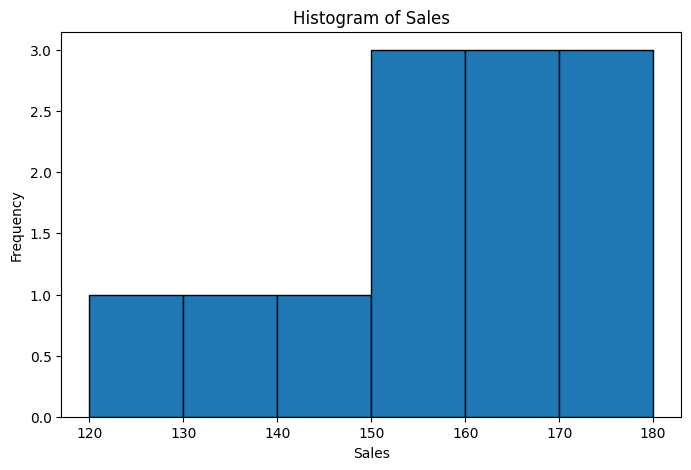

In [51]:
# --------------------------------------------
# 1. DESCRIPTIVE STATISTICS
# Dataset: Sales data
# --------------------------------------------

sales_data = pd.DataFrame({
    "sales": [120, 135, 150, 160, 145, 155, 170, 180, 175, 165, 160, 158]
})

print("\n" + "="*50)
print("1. DESCRIPTIVE STATISTICS")
print("="*50)

mean_val = sales_data["sales"].mean()
median_val = sales_data["sales"].median()
mode_val = sales_data["sales"].mode()[0]
variance_val = sales_data["sales"].var()
std_dev_val = sales_data["sales"].std()

print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Mode: {mode_val}")
print(f"Variance: {variance_val:.2f}")
print(f"Standard Deviation: {std_dev_val:.2f}")

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(sales_data["sales"], bins=6, edgecolor="black")
plt.title("Histogram of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


# Inferential Statistics (t-test)

In [52]:
# --------------------------------------------
# 2. INFERENTIAL STATISTICS
# Independent Samples t-test
# Study: Tutored vs Non-Tutored students
# --------------------------------------------

tutored_scores = np.array([78, 82, 85, 88, 90, 84, 79, 91, 87, 86])
non_tutored_scores = np.array([70, 72, 68, 75, 74, 69, 73, 71, 67, 76])

print("\n" + "="*50)
print("2. INFERENTIAL STATISTICS - INDEPENDENT T-TEST")
print("="*50)

t_stat, p_value = stats.ttest_ind(tutored_scores, non_tutored_scores, equal_var=True)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Interpretation: There is a statistically significant difference between the groups.")
else:
    print("Interpretation: There is no statistically significant difference between the groups.")




2. INFERENTIAL STATISTICS - INDEPENDENT T-TEST
T-statistic: 8.0598
P-value: 0.0000
Interpretation: There is a statistically significant difference between the groups.


# Correlation Analysis

In [53]:

# --------------------------------------------
# 3. CORRELATION ANALYSIS
# Variables: advertising spend, awareness, sales revenue
# --------------------------------------------

advertising_data = pd.DataFrame({
    "advertising_spend": [10, 12, 15, 18, 20, 25, 28, 30, 35, 40],
    "awareness":         [30, 35, 40, 45, 50, 58, 62, 65, 72, 80],
    "sales_revenue":     [100, 110, 125, 140, 150, 170, 180, 190, 210, 230]
})

print("\n" + "="*50)
print("3. CORRELATION ANALYSIS")
print("="*50)

corr_matrix = advertising_data.corr()
print(corr_matrix)

# Optional: pairwise Pearson tests
for col1 in advertising_data.columns:
    for col2 in advertising_data.columns:
        if col1 != col2:
            r, p = stats.pearsonr(advertising_data[col1], advertising_data[col2])
            print(f"Correlation between {col1} and {col2}: r = {r:.4f}, p = {p:.4f}")




3. CORRELATION ANALYSIS
                   advertising_spend  awareness  sales_revenue
advertising_spend           1.000000   0.997685       0.998638
awareness                   0.997685   1.000000       0.999346
sales_revenue               0.998638   0.999346       1.000000
Correlation between advertising_spend and awareness: r = 0.9977, p = 0.0000
Correlation between advertising_spend and sales_revenue: r = 0.9986, p = 0.0000
Correlation between awareness and advertising_spend: r = 0.9977, p = 0.0000
Correlation between awareness and sales_revenue: r = 0.9993, p = 0.0000
Correlation between sales_revenue and advertising_spend: r = 0.9986, p = 0.0000
Correlation between sales_revenue and awareness: r = 0.9993, p = 0.0000


# Linear Regression


4. LINEAR REGRESSION
                            OLS Regression Results                            
Dep. Variable:          sales_revenue   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     2930.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.50e-11
Time:                        15:32:05   Log-Likelihood:                -21.738
No. Observations:                  10   AIC:                             47.48
Df Residuals:                       8   BIC:                             48.08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const           

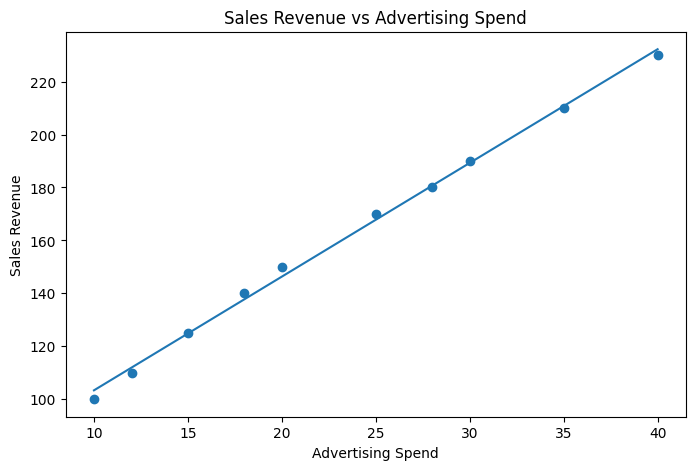

In [54]:

# --------------------------------------------
# 4. LINEAR REGRESSION
# Dependent variable: sales_revenue
# Independent variable: advertising_spend
# --------------------------------------------

print("\n" + "="*50)
print("4. LINEAR REGRESSION")
print("="*50)

X = advertising_data["advertising_spend"]
y = advertising_data["sales_revenue"]

X_const = sm.add_constant(X)   # adds intercept
linear_model = sm.OLS(y, X_const).fit()

print(linear_model.summary())

# Scatter plot with regression line
plt.figure(figsize=(8, 5))
plt.scatter(advertising_data["advertising_spend"], advertising_data["sales_revenue"])
predicted_y = linear_model.predict(X_const)
plt.plot(advertising_data["advertising_spend"], predicted_y)
plt.title("Sales Revenue vs Advertising Spend")
plt.xlabel("Advertising Spend")
plt.ylabel("Sales Revenue")
plt.show()



# Multivariate Analysis

In [55]:

# --------------------------------------------
# 5. MULTIVARIATE ANALYSIS
# Multiple Regression: House price prediction
# Predictors: size, bedrooms, location_score
# --------------------------------------------

house_data = pd.DataFrame({
    "price": [200, 220, 250, 270, 300, 320, 350, 370, 400, 450],
    "size": [1000, 1100, 1200, 1350, 1500, 1600, 1750, 1800, 2000, 2200],
    "bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "location_score": [4, 5, 5, 6, 6, 7, 7, 8, 8, 9]
})

print("\n" + "="*50)
print("5. MULTIVARIATE ANALYSIS - MULTIPLE REGRESSION")
print("="*50)

multi_model = smf.ols("price ~ size + bedrooms + location_score", data=house_data).fit()
print(multi_model.summary())




5. MULTIVARIATE ANALYSIS - MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     665.5
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           5.88e-08
Time:                        15:32:05   Log-Likelihood:                -28.500
No. Observations:                  10   AIC:                             65.00
Df Residuals:                       6   BIC:                             66.21
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

# ANOVA

In [56]:

# --------------------------------------------
# 6. ANOVA
# Compare exam scores under 3 teaching methods
# --------------------------------------------

method_A = np.array([70, 72, 68, 75, 74, 71, 69])
method_B = np.array([78, 80, 82, 79, 81, 77, 83])
method_C = np.array([85, 88, 84, 87, 86, 89, 90])

print("\n" + "="*50)
print("6. ONE-WAY ANOVA")
print("="*50)

f_stat, p_val = stats.f_oneway(method_A, method_B, method_C)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Interpretation: At least one teaching method differs significantly.")
else:
    print("Interpretation: No significant difference among teaching methods.")

# Optional Tukey post-hoc test
anova_df = pd.DataFrame({
    "score": np.concatenate([method_A, method_B, method_C]),
    "method": (["A"] * len(method_A)) + (["B"] * len(method_B)) + (["C"] * len(method_C))
})

tukey = pairwise_tukeyhsd(endog=anova_df["score"], groups=anova_df["method"], alpha=0.05)
print("\nPost-hoc Tukey Test:")
print(tukey)




6. ONE-WAY ANOVA
F-statistic: 81.8353
P-value: 0.0000
Interpretation: At least one teaching method differs significantly.

Post-hoc Tukey Test:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   8.7143    0.0  5.5732 11.8554   True
     A      C  15.7143    0.0 12.5732 18.8554   True
     B      C      7.0 0.0001  3.8589 10.1411   True
----------------------------------------------------


# Chi-Square Test

In [57]:

# --------------------------------------------
# 7. CHI-SQUARE TEST
# Relationship between satisfaction and service type
# --------------------------------------------

chi_data = pd.DataFrame({
    "Service_Type": ["Online", "Online", "Online", "InPerson", "InPerson", "InPerson"],
    "Satisfaction": ["Satisfied", "Neutral", "Dissatisfied", "Satisfied", "Neutral", "Dissatisfied"],
    "Count": [50, 20, 10, 30, 25, 15]
})

print("\n" + "="*50)
print("7. CHI-SQUARE TEST")
print("="*50)

contingency_table = chi_data.pivot(index="Service_Type", columns="Satisfaction", values="Count")
print("Contingency Table:")
print(contingency_table)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected Frequencies:")
print(expected)

if p < 0.05:
    print("Interpretation: There is a significant relationship between service type and satisfaction.")
else:
    print("Interpretation: There is no significant relationship between service type and satisfaction.")




7. CHI-SQUARE TEST
Contingency Table:
Satisfaction  Dissatisfied  Neutral  Satisfied
Service_Type                                  
InPerson                15       25         30
Online                  10       20         50

Chi-square statistic: 5.9152
P-value: 0.0519
Degrees of freedom: 2
Expected Frequencies:
[[11.66666667 21.         37.33333333]
 [13.33333333 24.         42.66666667]]
Interpretation: There is no significant relationship between service type and satisfaction.


# Data Visualization


8. DATA VISUALIZATION


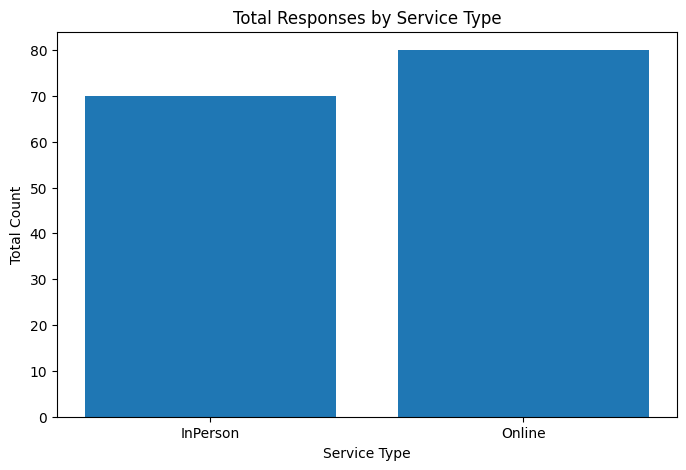

/tmp/ipykernel_3942/1439290786.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([method_A, method_B, method_C], labels=["Method A", "Method B", "Method C"])


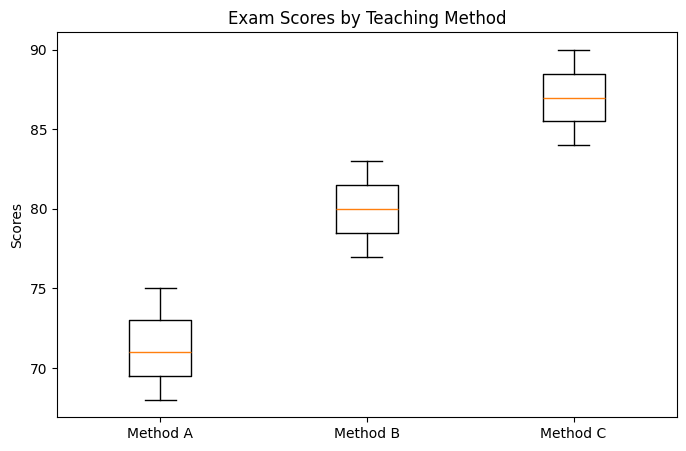

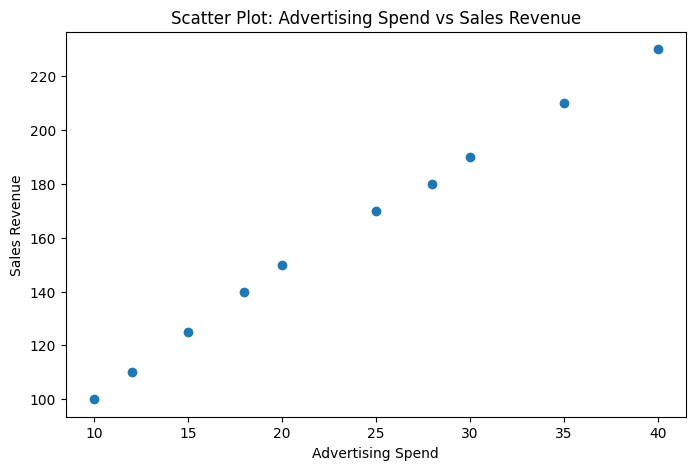

In [58]:

# --------------------------------------------
# 8. DATA VISUALIZATION
# At least 3 plots: bar, box, scatter
# --------------------------------------------

print("\n" + "="*50)
print("8. DATA VISUALIZATION")
print("="*50)

# Bar plot
plt.figure(figsize=(8, 5))
service_summary = contingency_table.sum(axis=1)
plt.bar(service_summary.index, service_summary.values)
plt.title("Total Responses by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Total Count")
plt.show()

# Box plot
plt.figure(figsize=(8, 5))
plt.boxplot([method_A, method_B, method_C], labels=["Method A", "Method B", "Method C"])
plt.title("Exam Scores by Teaching Method")
plt.ylabel("Scores")
plt.show()

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(advertising_data["advertising_spend"], advertising_data["sales_revenue"])
plt.title("Scatter Plot: Advertising Spend vs Sales Revenue")
plt.xlabel("Advertising Spend")
plt.ylabel("Sales Revenue")
plt.show()



# Intepretation

In [59]:

# --------------------------------------------
# COMBINED INTERPRETATION NOTES
# --------------------------------------------

print("\n" + "="*50)
print("SUMMARY NOTES")
print("="*50)
print("""
1. Descriptive statistics summarize the distribution of sales data.
2. The t-test checks whether tutored and non-tutored students differ significantly.
3. Correlation shows the strength and direction of relationships among variables.
4. Linear regression estimates how advertising spend predicts sales revenue.
5. Multiple regression identifies which house features significantly predict house prices.
6. ANOVA compares mean scores across three teaching methods.
7. Chi-square tests association between two categorical variables.
8. Visualizations help reveal distribution, spread, and relationships in data.
""")


SUMMARY NOTES

1. Descriptive statistics summarize the distribution of sales data.
2. The t-test checks whether tutored and non-tutored students differ significantly.
3. Correlation shows the strength and direction of relationships among variables.
4. Linear regression estimates how advertising spend predicts sales revenue.
5. Multiple regression identifies which house features significantly predict house prices.
6. ANOVA compares mean scores across three teaching methods.
7. Chi-square tests association between two categorical variables.
8. Visualizations help reveal distribution, spread, and relationships in data.



# Explanation

In modern data science and artificial intelligence research, statistical analysis is frequently performed using computational tools that enable efficient data processing, reproducibility, and transparency. Python has become one of the most widely used programming languages for statistical analysis because it provides powerful libraries for data manipulation, statistical modeling, and visualization.

In this study, Python is used to implement a comprehensive quantitative analysis covering several statistical techniques, including descriptive statistics, inferential testing, correlation analysis, regression modeling, multivariate analysis, ANOVA, chi-square testing, and data visualization. These techniques represent core components of quantitative research methodology and allow researchers to extract meaningful insights from numerical data.

The analysis is conducted using a combination of widely adopted Python libraries. The Pandas library is used for data manipulation and dataset management, allowing structured handling of tabular data. NumPy provides numerical computing capabilities that support statistical calculations. SciPy is used for inferential statistical tests such as t-tests and chi-square tests, enabling hypothesis testing and significance analysis. Statsmodels is utilized for regression analysis and statistical modeling, as it provides detailed outputs including coefficient estimates, p-values, confidence intervals, and goodness-of-fit metrics that are commonly required in empirical research. Finally, Matplotlib is used for visualizing data distributions and relationships through plots such as histograms, bar charts, box plots, and scatter plots.

The integration of these tools allows the entire quantitative workflow—from descriptive analysis to advanced statistical modeling—to be implemented within a single computational environment. This approach enhances reproducibility, as the analytical procedures can be executed and verified by other researchers using the same code and datasets. Furthermore, it reflects current best practices in data science and artificial intelligence, where statistical reasoning and computational analysis are combined to support evidence-based decision-making.

Through this implementation, Python serves not only as a programming tool but also as a platform for conducting rigorous quantitative research analysis.